In [3]:
from models.ChronosModel import ChronosModel
import yaml 
import pandas as pd
%load_ext autoreload
%autoreload 2


data = pd.read_csv("input/processed/data.csv", index_col=0, parse_dates=True)
with open("config.yaml") as f: 
    config = yaml.safe_load(f)
    
model = ChronosModel(config["TreeModel"], quantiles=[0.1,0.5,0.9])
preds = model.rolling_forecast(data.iloc[:3000])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading Chronos model: amazon/chronos-2


 33%|███▎      | 41/125 [00:22<00:46,  1.79it/s]


In [ ]:
from models.TreeModel import TreeModel

model = TreeModel(config=["TreeModel"])

,true,pred_q0.1,pred_q0.5,pred_q0.9
DateTime,,,,
2015-03-29 07:00:00+00:00,14.90,11.048536,16.704794,22.292173
2015-03-29 08:00:00+00:00,14.92,11.616545,18.293522,24.565338
2015-03-29 09:00:00+00:00,14.96,10.903090,18.485916,25.522547
2015-03-29 10:00:00+00:00,14.95,11.190756,19.866093,28.052410
2015-03-29 11:00:00+00:00,12.14,11.111490,19.856802,28.873613
...,...,...,...,...
2015-05-09 02:00:00+00:00,15.75,15.910288,20.099442,24.386763
2015-05-09 03:00:00+00:00,15.66,15.933263,20.572744,25.167734
2015-05-09 04:00:00+00:00,16.86,16.136314,21.703629,26.749733


In [7]:
(y_true.index == y_pred.index).all()

np.True_

In [57]:
from utils.losses import *
from pathlib import Path
import pandas as pd

# assume the latest prediction is always the best prediction
tree_file = [f for f in (Path("output") / "tree_based").rglob("*predictions.csv")][-1]
linear_file = [f for f in (Path("output") / "linear").rglob("*predictions.csv")][-1]
chronos_file = [f for f in (Path("output") / "chronos").rglob("*predictions.csv")][-1]

tree_df = pd.read_csv(tree_file, index_col=0)
linear_df = pd.read_csv(linear_file, index_col=0)
chronos_df = pd.read_csv(chronos_file, index_col=0)

avg_losses, avg_covs, avg_mae_losses = {}, {}, {}

for name, df in zip(["tree" ,"linear", "chronos"],[tree_df, linear_df, chronos_df]):
    avg_loss = average_pinball_loss(df)
    print(f"Average pinball loss {name}: {avg_loss.mean():.2f}")
    avg_coverage = coverage_within_range(df)
    print(f"Average coverage {name}: {avg_coverage.mean():.1%}")
    mae = (df.iloc[:,0] - df.iloc[:,2]).abs()
    print(f"Mean Absolute Error: {mae.mean():.2f}")

    avg_losses[name] = avg_loss
    avg_covs[name] = avg_coverage
    avg_mae_losses[name] = mae

Average pinball loss tree: 3.55
Average coverage tree: 55.4%
Mean Absolute Error: 9.78
Average pinball loss linear: 6.52
Average coverage linear: 76.4%
Mean Absolute Error: 18.91
Average pinball loss chronos: 2.83
Average coverage chronos: 76.1%
Mean Absolute Error: 8.87


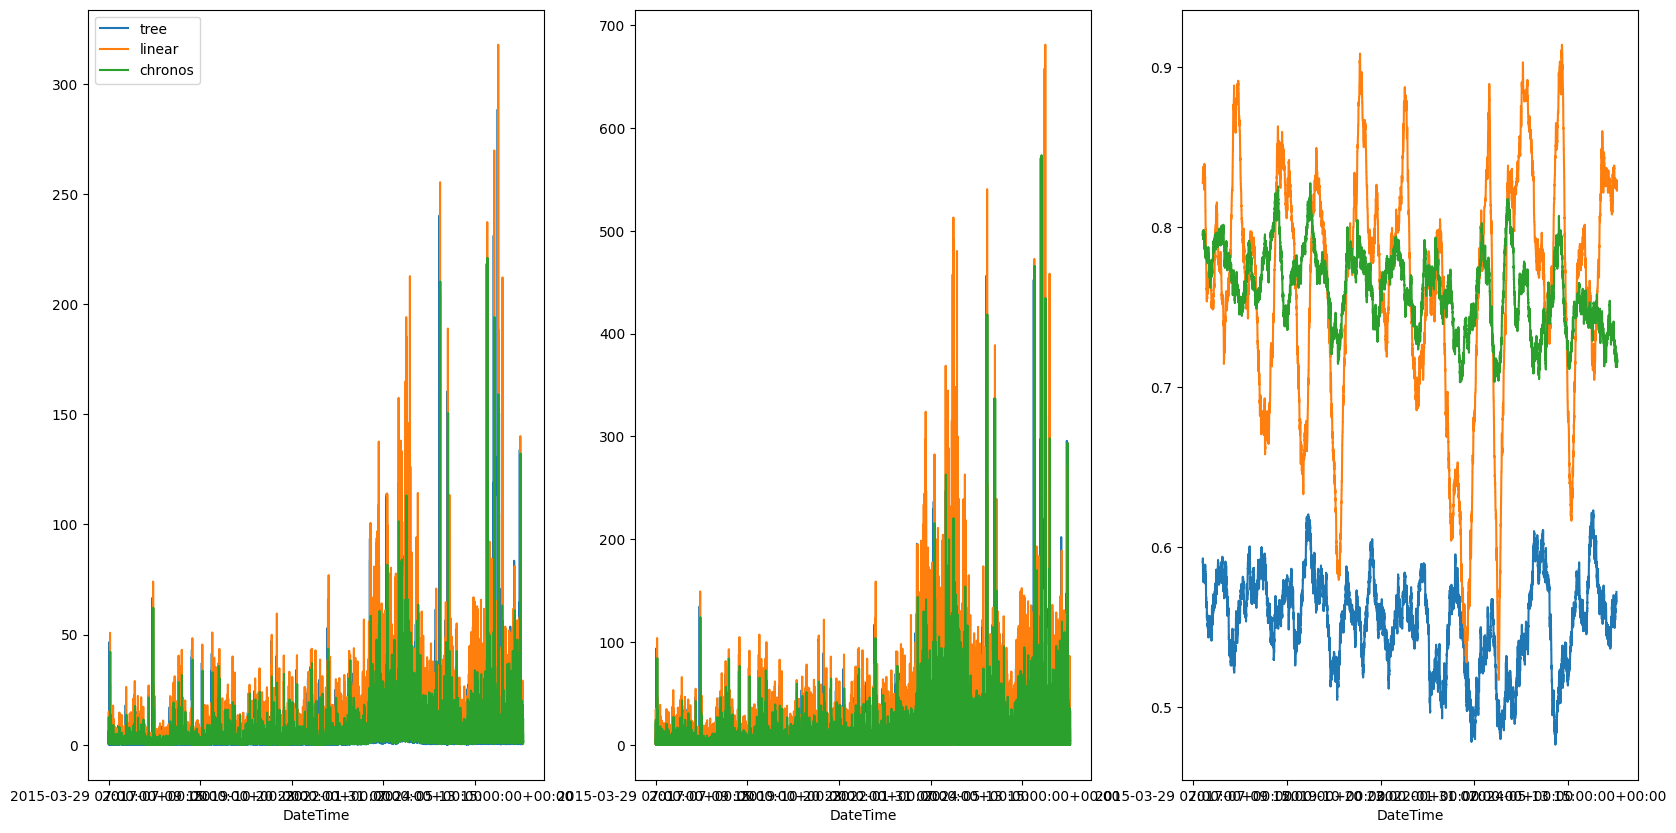

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(20,10))

for name in avg_covs: 

    avg_losses[name].plot(ax=axes[0], label=name)
    avg_mae_losses[name].plot(ax=axes[1], label=name)
    rolling_cov =  avg_covs[name].rolling(2000).mean()
    rolling_cov.plot(ax=axes[2], label=name)

axes[0].legend()